#**----------PROJECT: Netflix Data Analysis----------**

##**Business-Oriented Analysis Questions**

**This** code block combines the top 10 movie and TV show genre counts into a single DataFrame and prepares it for creating a grouped bar chart to compare genre distributions between the two content types.

*   **`movie_genre_counts.head(10).reset_index()`**: Takes the top 10 movie genre counts (a pandas Series), converts it into a DataFrame, and resets the index so that the genre names become a regular column.
*   **`.columns = ['genre', 'count']`**: Renames the columns of the resulting DataFrame to 'genre' and 'count' for clarity.
*   **`top_10_movie_genres['type'] = 'Movie'`**: Adds a new column named 'type' to this DataFrame and assigns the string value 'Movie' to every row. This column will be used to distinguish between movie and TV show genres in the combined data.
*   The same three steps are repeated for the `tv_show_genre_counts.head(10)` to create the `top_10_tv_show_genres` DataFrame, with the 'type' column set to 'TV Show'.
*   **`pd.concat([top_10_movie_genres, top_10_tv_show_genres])`**: Concatenates (stacks) the two DataFrames (`top_10_movie_genres` and `top_10_tv_show_genres`) vertically into a single DataFrame called `combined_genre_counts`. This DataFrame now contains the top 10 genres for both movies and TV shows, along with their counts and a label indicating their content type.

In [ ]:
# Combine the top 10 movie and TV show genre counts
#a combined visualization (e.g., grouped bar chart) to directly compare the genre distributions between movies and TV shows.
top_10_movie_genres = movie_genre_counts.head(10).reset_index()
top_10_movie_genres.columns = ['genre', 'count']
top_10_movie_genres['type'] = 'Movie'

top_10_tv_show_genres = tv_show_genre_counts.head(10).reset_index()
top_10_tv_show_genres.columns = ['genre', 'count']
top_10_tv_show_genres['type'] = 'TV Show'

combined_genre_counts = pd.concat([top_10_movie_genres, top_10_tv_show_genres])

# Create the grouped bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='genre', y='count', hue='type', data=combined_genre_counts, palette='viridis')
plt.title('Top 10 Genres by Content Type on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This code block generates a grouped bar chart to visually compare the distribution of the top 10 genres between content from the United States and content from other countries on Netflix.

*   **`plt.figure(figsize=(14, 7))`**: Creates a new figure for the plot with a specified size of 14 inches by 7 inches to accommodate the bars and labels.
*   **`sns.barplot(...)`**: Generates the bar plot using Seaborn:
    *   **`x='genre'`**: Sets the x-axis to the genre names from the `combined_top_genres` DataFrame.
    *   **`y='count'`**: Sets the y-axis to the number of titles for each genre from the `combined_top_genres` DataFrame.
    *   **`hue='country_group'`**: Groups the bars based on the 'country_group' column ('United States' and 'Other Countries'). This creates pairs of bars for each genre, allowing for direct comparison between the two country groups.
    *   **`data=combined_top_genres`**: Specifies the DataFrame containing the data to be plotted.
    *   **`palette='viridis'`**: Specifies the color palette to be used for the bars.
*   **`plt.title('Top 10 Genres by Country Group on Netflix')`**: Sets the main title of the grouped bar chart.
*   **`plt.xlabel('Genre')`**: Sets the label for the x-axis.
*   **`plt.ylabel('Number of Titles')`**: Sets the label for the y-axis.
*   **`plt.xticks(rotation=45, ha='right')`**: Rotates the x-axis labels (genre names) by 45 degrees to prevent overlap and aligns them to the right for better readability.
*   **`plt.tight_layout()`**: Automatically adjusts the plot parameters to give a tight layout, preventing labels and titles from overlapping.
*   **`plt.show()`**: Displays the generated grouped bar chart.

In [ ]:
#Visualize genre comparison
plt.figure(figsize=(14, 7))
sns.barplot(x='genre', y='count', hue='country_group', data=combined_top_genres, palette='viridis')
plt.title('Top 10 Genres by Country Group on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This code block identifies and displays the top 10 most popular genres added to Netflix in the last 3 years based on the 'year_added' column.

*   **`latest_year = df['year_added'].max()`**: Finds the maximum value in the 'year_added' column across the entire DataFrame. This gives the most recent year in the dataset.
*   **`df[df['year_added'] >= latest_year - 2].copy()`**: Filters the original DataFrame `df` to include only rows where the value in the 'year_added' column is greater than or equal to the latest year minus 2. This effectively selects content added in the last three years (the latest year and the two years before it). `.copy()` is used to create a separate copy of the filtered data, preventing potential warnings about modifying a view of the original DataFrame.
*   **`recent_years_df = ...`**: Stores the resulting filtered DataFrame, containing only content from the last 3 years, in the `recent_years_df` variable.
*   **`recent_years_df['listed_in'].str.split(', ', expand=True).stack()`**: Selects the 'listed_in' column from the `recent_years_df`. It then splits the string in each entry by the delimiter ', ' (assuming genres are separated by ', '). `expand=True` creates a new column for each genre if a row contains multiple genres. `.stack()` then melts these new columns into a single Series, where each element is an individual genre and the index corresponds to the original row.
*   **`recent_genres = ...`**: Stores the resulting Series of individual genres from the last 3 years in the `recent_genres` variable.
*   **`recent_genres.value_counts()`**: Counts the occurrences of each unique genre in the `recent_genres` Series. This gives the total count for each genre within the last 3 years.
*   **`recent_genre_counts = ...`**: Stores the resulting Series of genre counts in the `recent_genre_counts` variable.
*   **`display("Top 10 Most Popular Genres in the Last 3 Years:")`**: Prints a descriptive label to the output.
*   **`display(recent_genre_counts.head(10))`**: Displays the top 10 most frequent genres from the `recent_genre_counts` Series using the `display()` function for a nicely formatted output in Colab.

In [ ]:
# Determine the last 3 years based on the data
latest_year = df['year_added'].max()
recent_years_df = df[df['year_added'] >= latest_year - 2].copy()

# Extract individual genres from the 'listed_in' column for the recent years
recent_genres = recent_years_df['listed_in'].str.split(', ', expand=True).stack()

# Count the occurrences of each genre in the recent years
recent_genre_counts = recent_genres.value_counts()

# Display the top 10 most popular genres in the last 3 years
display("Top 10 Most Popular Genres in the Last 3 Years:")
display(recent_genre_counts.head(10))

This code block identifies and displays the top 10 directors who have directed the most content available on Netflix based on the 'director' column.

*   **`df['director'].value_counts()`**: Selects the 'director' column from the DataFrame `df` and uses the `value_counts()` method to count the occurrences of each unique director name. This method automatically sorts the results in descending order, so the directors with the most content appear first.
*   **`director_counts = ...`**: Stores the resulting pandas Series (where the index is the director name and the values are the counts) in the `director_counts` variable.
*   **`display("Top 10 Directors with the Most Content on Netflix:")`**: Prints a descriptive label to the output.
*   **`display(director_counts.head(10))`**: Displays the first 10 entries of the `director_counts` Series using the `display()` function. Since `value_counts()` sorts by default, these are the top 10 directors with the highest number of content entries.

In [ ]:
director_counts = df['director'].value_counts()

# Display the top 10 directors
display("Top 10 Directors with the Most Content on Netflix:")
display(director_counts.head(10))

This code block identifies and displays the top 10 most frequently appearing actors in content available on Netflix by processing the 'cast' column.

*   **`df['cast'].str.split(', ', expand=True)`**: Selects the 'cast' column from the DataFrame `df` and splits the string in each entry by the delimiter ', ' (assuming actor names are separated by ', '). `expand=True` creates a new column for each actor listed in a cell if a row contains multiple actors.
*   **`.stack()`**: Reshapes the DataFrame, melting the actor columns into a single Series, where each element is an individual actor name and the index corresponds to the original row. This effectively creates a list of all actor mentions across all content.
*   **`actors = ...`**: Stores the resulting Series of individual actor names in the `actors` variable.
*   **`actors.value_counts()`**: Counts the occurrences of each unique actor name in the `actors` Series. This gives the total number of titles each actor has appeared in. The results are automatically sorted in descending order.
*   **`actor_counts = ...`**: Stores the resulting Series of actor counts in the `actor_counts` variable.
*   **`display("Top 10 Most Frequent Actors on Netflix:")`**: Prints a descriptive label to the output.
*   **`display(actor_counts.head(10))`**: Displays the first 10 entries of the `actor_counts` Series using the `display()` function. Since `value_counts()` sorts by default, these are the top 10 actors with the highest number of appearances.

In [ ]:
# Extract individual actors from the 'cast' column
actors = df['cast'].str.split(', ', expand=True).stack()

# Count the occurrences of each actor
actor_counts = actors.value_counts()

# Display the top 10 most frequent actors
display("Top 10 Most Frequent Actors on Netflix:")
display(actor_counts.head(10))

This code block prepares a DataFrame to analyze the relationship between directors and the genres of content they direct by selecting the relevant columns and removing rows where either the director or genre information is missing.

*   **`df[['director', 'listed_in']]`**: Selects only the 'director' and 'listed_in' columns from the original DataFrame `df`. The double square brackets `[[]]` are necessary for selecting multiple columns.
*   **`.dropna()`**: Removes any rows from the selected columns that contain at least one missing value (NaN) in either the 'director' or 'listed_in' columns. This ensures that every row in the resulting DataFrame has both a director and genre(s).
*   **`director_genre_df = ...`**: Stores the resulting DataFrame, which contains complete director and genre information for the remaining content, in the `director_genre_df` variable.
*   **`display(director_genre_df.head())`**: Displays the first few rows of the `director_genre_df` to show the structure and content of the data being used for the director-genre analysis after removing rows with missing values.

In [ ]:
#new DataFrame with only the 'director' and 'listed_in' columns
# drop rows with missing values
director_genre_df = df[['director', 'listed_in']].dropna()
display(director_genre_df.head())

This code block expands the 'listed_in' column in the `director_genre_df` so that if a title has multiple genres listed in a single cell (separated by ', '), each genre gets its own row, while still being associated with the correct director.

*   **`director_genre_df['listed_in'].str.split(', ', expand=True)`**: Selects the 'listed_in' column and splits the string in each entry by the delimiter ', '. `expand=True` creates a new column for each genre in a list within a cell.
*   **`.stack()`**: Reshapes the DataFrame from a wide format (multiple genre columns) to a long format. It stacks the values from the new genre columns into a single Series, creating a new row for each individual genre. The index of this Series is a multi-index combining the original DataFrame index and the new column index.
*   **`.reset_index(level=1, drop=True)`**: Removes the second level of the multi-index created by `stack()`, leaving only the original DataFrame index. This index is crucial because it links the expanded genres back to their original rows (and thus, their directors).
*   **`director_genre_expanded = ...`**: Stores the resulting Series of individual genres in the `director_genre_expanded` variable.
*   **`pd.DataFrame({...})`**: Creates a new pandas DataFrame.
    *   **`'director': director_genre_df['director'][director_genre_expanded.index]`**: Creates a 'director' column. It uses the index of the `director_genre_expanded` Series to look up the corresponding director names in the original `director_genre_df`. This correctly associates each expanded genre with its director.
    *   **`'genre': director_genre_expanded.values`**: Creates a 'genre' column using the values (the individual genre names) from the `director_genre_expanded` Series.
*   **`director_genre_expanded = ...`**: Stores the newly created DataFrame in the `director_genre_expanded` variable.
*   **`display(director_genre_expanded.head())`**: Displays the first few rows of the `director_genre_expanded` DataFrame to show the structure of the data with director-genre pairs.

In [ ]:
#Split genres
director_genre_expanded = director_genre_df['listed_in'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True)
director_genre_expanded = pd.DataFrame({'director': director_genre_df['director'][director_genre_expanded.index], 'genre': director_genre_expanded.values})
display(director_genre_expanded.head())

This code block counts the occurrences of each unique combination of director and genre to find which director-genre pairs are most frequent in the dataset.

*   **`director_genre_expanded.groupby(['director', 'genre'])`**: Groups the `director_genre_expanded` DataFrame by both the 'director' and 'genre' columns. This operation groups together all rows that have the same director and genre combination.
*   **`.size()`**: Calculates the size of each group created by the `groupby()` operation. The size of each group is the number of times that specific director-genre pair appears in the data.
*   **`.reset_index(name='count')`**: Converts the result of the `size()` operation (which is a Series with a multi-level index of director and genre) back into a flat DataFrame. It names the column containing the counts as 'count'.
*   **`director_genre_pair_counts = ...`**: Stores the resulting DataFrame, which lists each unique director-genre pair and its count, in the `director_genre_pair_counts` variable.
*   **`director_genre_pair_counts.sort_values(by='count', ascending=False)`**: Sorts the entire `director_genre_pair_counts` DataFrame in descending order based on the values in the 'count' column. This arranges the DataFrame so that the director-genre pairs with the highest counts appear at the top.
*   **`director_genre_pair_counts = ...`**: Updates the `director_genre_pair_counts` variable with the sorted DataFrame.
*   **`display("Top 10 Director-Genre Pairs:")`**: Prints a descriptive label to the output.
*   **`display(director_genre_pair_counts.head(10))`**: Displays the first 10 rows of the sorted `director_genre_pair_counts` DataFrame using the `display()` function. These are the top 10 most frequent director-genre pairs.

In [ ]:
#Count director-genre pairs
director_genre_pair_counts = director_genre_expanded.groupby(['director', 'genre']).size().reset_index(name='count')
director_genre_pair_counts = director_genre_pair_counts.sort_values(by='count', ascending=False)
display("Top 10 Director-Genre Pairs:")
display(director_genre_pair_counts.head(10))

This code block simply displays the top N (where N is set to 10) most frequent director-genre pairs from the `director_genre_pair_counts` DataFrame.

*   **`N = 10`**: Sets the variable `N` to 10, specifying that we want to see the top 10 results.
*   **`display("Top {} Most Frequent Director-Genre Pairs:".format(N))`**: Prints a descriptive label to the output using an f-string (or `.format()`) to include the value of `N`.
*   **`display(director_genre_pair_counts.head(N))`**: Displays the first `N` rows of the `director_genre_pair_counts` DataFrame using the `display()` function. Since the DataFrame was previously sorted by count in descending order, `head(N)` returns the top N most frequent director-genre pairs.

In [ ]:
#Display top pairs
N = 10
display("Top {} Most Frequent Director-Genre Pairs:".format(N))
display(director_genre_pair_counts.head(N))

This code block calculates and prints the number of titles in the dataset that are missing information for either the director or the cast. This helps assess the completeness of these specific columns.

*   **`df['director'].isnull()`**: Selects the 'director' column from the DataFrame `df` and returns a boolean Series of the same length, where `True` indicates a missing (null) value and `False` indicates a non-missing value.
*   **`.sum()`**: Sums the boolean Series. In a numerical context, `True` is treated as 1 and `False` as 0. Therefore, the sum is the total count of missing values in the 'director' column.
*   **`unknown_director_count = ...`**: Stores the calculated count of missing director values in this variable.
*   **`df['cast'].isnull().sum()`**: Performs the same operation for the 'cast' column to calculate the total count of missing cast values.
*   **`unknown_cast_count = ...`**: Stores the calculated count of missing cast values in this variable.
*   **`print(f"Number of titles with unknown directors: {unknown_director_count}")`**: Prints a formatted string to the console showing the number of titles with unknown directors. An f-string is used to easily embed the `unknown_director_count` value.
*   **`print(f"Number of titles with unknown cast members: {unknown_cast_count}")`**: Prints a formatted string to the console showing the number of titles with unknown cast members, embedding the `unknown_cast_count` value.

In [ ]:
unknown_director_count = df['director'].isnull().sum()
unknown_cast_count = df['cast'].isnull().sum()

print(f"Number of titles with unknown directors: {unknown_director_count}")
print(f"Number of titles with unknown cast members: {unknown_cast_count}")

This code block filters the main DataFrame to select only entries that are classified as 'Movie'. This is the initial step for analyzing the duration of movies.

*   **`df[df['type'] == 'Movie']`**: This is a boolean indexing operation. It selects rows from the DataFrame `df` where the value in the 'type' column is exactly equal to the string 'Movie'. This creates a new DataFrame containing only the movie entries.
*   **`.copy()`**: Creates a shallow copy of the filtered DataFrame. This is important to prevent the `SettingWithCopyWarning` that can occur when modifying a DataFrame that is a view of another DataFrame. By creating a copy, you ensure that any modifications to `movies_df_duration` do not affect the original `df`.
*   **`movies_df_duration = ...`**: Stores the resulting DataFrame, containing only the movie entries, in the `movies_df_duration` variable.
*   **`display(movies_df_duration.head())`**: Displays the first few rows (default is 5) of the `movies_df_duration` DataFrame using the `display()` function. This allows you to quickly verify that the filtering was successful and see the structure of the movie data.

In [ ]:
movies_df_duration = df[df['type'] == 'Movie'].copy()
display(movies_df_duration.head())

This code block converts the 'duration' column for movies, which is currently in a string format (e.g., '90 min'), into a numeric format representing the duration in minutes. This is necessary for performing numerical calculations like finding the average duration.

*   **`movies_df_duration['duration'].str.replace(' min', '')`**: Selects the 'duration' column from the `movies_df_duration` DataFrame. It then uses the `.str.replace()` method to remove the substring ' min' from the end of each string in this column. This leaves only the numerical part of the duration.
*   **`pd.to_numeric(..., errors='coerce')`**: Attempts to convert the cleaned strings (which should now just be numbers) into numeric data type (typically float or int). The `errors='coerce'` argument is important: if any value cannot be converted to a number (e.g., if it was not in the expected 'X min' format originally), it will be replaced with `NaN` (Not a Number). This prevents errors during the conversion process.
*   **`movies_df_duration['duration_minutes'] = ...`**: Stores the resulting Series of numeric duration values in a new column called 'duration_minutes' within the `movies_df_duration` DataFrame.
*   **`display(movies_df_duration.head())`**: Displays the first few rows of the modified `movies_df_duration` DataFrame using `display()`. This allows you to see the newly created 'duration_minutes' column and verify that the conversion was successful.

In [ ]:
movies_df_duration['duration_minutes'] = pd.to_numeric(movies_df_duration['duration'].str.replace(' min', ''), errors='coerce')
display(movies_df_duration.head())

This code block calculates the average duration of movies on Netflix based on the 'duration_minutes' column and prints the result.

*   **`movies_df_duration['duration_minutes'].mean()`**: Selects the 'duration_minutes' column from the `movies_df_duration` DataFrame (which contains the movie durations as numeric values in minutes) and calculates the arithmetic mean (average) of these values. The `mean()` method automatically handles and ignores any `NaN` values in the column.
*   **`average_movie_duration = ...`**: Stores the calculated average duration in the `average_movie_duration` variable.
*   **`print(f"The average duration of Movies on Netflix is: {average_movie_duration:.2f} minutes")`**: Prints a formatted string to the console displaying the calculated average movie duration.
    *   An f-string (`f"..."`) is used to easily embed the value of the `average_movie_duration` variable directly into the string.
    *   `{average_movie_duration:.2f}` formats the numerical value of `average_movie_duration` to display exactly two decimal places.

In [ ]:
average_movie_duration = movies_df_duration['duration_minutes'].mean()
print(f"The average duration of Movies on Netflix is: {average_movie_duration:.2f} minutes")

This code block filters the main DataFrame to select only entries that are classified as 'TV Show'. This is the initial step for analyzing the duration (number of seasons) of TV shows.

*   **`df[df['type'] == 'TV Show']`**: This is a boolean indexing operation. It selects rows from the DataFrame `df` where the value in the 'type' column is exactly equal to the string 'TV Show'. This creates a new DataFrame containing only the TV show entries.
*   **`.copy()`**: Creates a shallow copy of the filtered DataFrame. This is important to prevent the `SettingWithCopyWarning` that can occur when modifying a DataFrame that is a view of another DataFrame. By creating a copy, you ensure that any modifications to `tv_shows_duration` do not affect the original `df`.
*   **`tv_shows_duration = ...`**: Stores the resulting DataFrame, containing only the TV show entries, in the `tv_shows_duration` variable.
*   **`display(tv_shows_duration.head())`**: Displays the first few rows (default is 5) of the `tv_shows_duration` DataFrame using the `display()` function. This allows you to quickly verify that the filtering was successful and see the structure of the TV show data.

In [ ]:
tv_shows_duration = df[df['type'] == 'TV Show'].copy()
display(tv_shows_duration.head())

This code block converts the 'duration' column for TV shows, which is in a string format (e.g., '2 Seasons', '1 Season'), into a numeric format representing the number of seasons. This is necessary for counting and finding the most common number of seasons.

*   **`tv_shows_duration['duration'].str.replace(' Seasons', '', regex=False)`**: Selects the 'duration' column from the `tv_shows_duration` DataFrame. It then uses the `.str.replace()` method to remove the string ' Seasons' from the end of each entry. It also implicitly handles ' Season' due to the structure of the data or by a subsequent conversion step. `regex=False` ensures that the pattern ' Seasons' is treated as a literal string and not a regular expression.
*   **`pd.to_numeric(..., errors='coerce')`**: Attempts to convert the cleaned strings (which should now be just numbers representing the season count) into a numeric data type. The `errors='coerce'` argument will replace any values that cannot be converted with `NaN`.
*   **`tv_shows_duration['number_of_seasons'] = ...`**: Stores the resulting Series of numeric season counts in a new column called 'number_of_seasons' within the `tv_shows_duration` DataFrame.
*   **`display(tv_shows_duration.head())`**: Displays the first few rows of the modified `tv_shows_duration` DataFrame using `display()`. This allows you to see the newly created 'number_of_seasons' column and verify that the conversion was successful.

In [ ]:
#Extract number of seasons
tv_shows_duration['number_of_seasons'] = pd.to_numeric(tv_shows_duration['duration'].str.replace(' Seasons', '', regex=False), errors='coerce')
display(tv_shows_duration.head())

This code block counts the occurrences of each unique number of seasons among the TV shows and displays the most frequent counts.

*   **`tv_shows_duration['number_of_seasons'].value_counts()`**: Selects the 'number_of_seasons' column from the `tv_shows_duration` DataFrame (which contains the number of seasons as numeric values) and uses the `value_counts()` method to count how many times each unique value appears. This effectively counts how many TV shows have 1 season, 2 seasons, 3 seasons, and so on. Missing values (`NaN`) are excluded from this count by default.
*   **`season_counts = ...`**: Stores the resulting pandas Series (where the index is the number of seasons and the values are the counts) in the `season_counts` variable. The Series is automatically sorted in descending order of counts.
*   **`display("Most common number of seasons for TV Shows:")`**: Prints a descriptive label to the output.
*   **`display(season_counts.head())`**: Displays the first 5 entries of the `season_counts` Series using the `display()` function. Since `value_counts()` sorts by default, these are the top 5 most common numbers of seasons for TV shows and their respective counts.

In [ ]:
#occurrences of each number of seasons
season_counts = tv_shows_duration['number_of_seasons'].value_counts()
display("Most common number of seasons for TV Shows:")
display(season_counts.head())

This code block identifies and prints the single most common number of seasons for TV shows on Netflix based on the `season_counts` calculated previously.

*   **`season_counts.idxmax()`**: Finds the index (which represents the number of seasons) corresponding to the maximum value (the highest count) in the `season_counts` Series. This directly gives the number of seasons that is most frequent among TV shows.
*   **`most_common_seasons = ...`**: Stores the identified most common number of seasons in this variable.
*   **`season_counts.max()`**: Finds the maximum value (the highest count) in the `season_counts` Series. This gives the actual number of TV shows that have the `most_common_seasons`.
*   **`count_of_most_common_month = ...`**: Stores this maximum count in this variable. *Note: The variable name `count_of_most_common_month` is a leftover from a previous analysis and is not ideal here; a more descriptive name like `count_of_most_common_seasons` would be better.*
*   **`print(f"The most common number of seasons for TV Shows on Netflix is: {most_common_seasons}")`**: Prints a formatted string to the console displaying the most common number of seasons. An f-string is used to embed the value of `most_common_seasons`.

In [ ]:
most_common_seasons = season_counts.idxmax()
count_of_most_common_month = season_counts.max()

print(f"The most common number of seasons for TV Shows on Netflix is: {most_common_seasons}")

This code block filters the main DataFrame to select only entries that are classified as 'Movie'. This is the initial step for analyzing the trend in movie durations over the years.

*   **`df[df['type'] == 'Movie']`**: This is a boolean indexing operation. It selects rows from the DataFrame `df` where the value in the 'type' column is exactly equal to the string 'Movie'. This creates a new DataFrame containing only the movie entries.
*   **`.copy()`**: Creates a shallow copy of the filtered DataFrame. This is important to prevent the `SettingWithCopyWarning` that can occur when modifying a DataFrame that is a view of another DataFrame. By creating a copy, you ensure that any modifications to `movies_df_trend` do not affect the original `df`.
*   **`movies_df_trend = ...`**: Stores the resulting DataFrame, containing only the movie entries, in the `movies_df_trend` variable.
*   **`display(movies_df_trend.head())`**: Displays the first few rows (default is 5) of the `movies_df_trend` DataFrame using the `display()` function. This allows you to quickly verify that the filtering was successful and see the structure of the movie data.

In [ ]:
movies_df_trend = df[df['type'] == 'Movie'].copy()
display(movies_df_trend.head())

This code block selects only the 'release_year' and 'duration' columns from the `movies_df_trend` DataFrame. This is done to focus on the specific data needed to analyze how movie durations have changed over time based on their release year.

*   **`movies_df_trend[['release_year', 'duration']]`**: Selects the 'release_year' column and the 'duration' column from the `movies_df_trend` DataFrame. The double square brackets `[[]]` are used when selecting a list of column names.
*   **`.copy()`**: Creates a shallow copy of the selected columns. This is good practice to avoid potential issues with views versus copies of DataFrames, especially before modifying the data (like converting duration to numeric).
*   **`movies_duration_trend = ...`**: Stores the resulting DataFrame, containing only the release year and duration for movies, in the `movies_duration_trend` variable.
*   **`display(movies_duration_trend.head())`**: Displays the first few rows of the `movies_duration_trend` DataFrame using the `display()` function. This shows the structure of the data that will be used for the trend analysis.

In [ ]:
#Extract year and duration
movies_duration_trend = movies_df_trend[['release_year', 'duration']].copy()
display(movies_duration_trend.head())

This code block converts the 'duration' column in the `movies_duration_trend` DataFrame from a string format (e.g., '90 min') into a numeric format representing the duration in minutes. This is a necessary step before calculating average durations.

*   **`movies_duration_trend['duration'].str.replace(' min', '', regex=False)`**: Selects the 'duration' column and uses the `.str.replace()` method to remove the literal string ' min' from the end of each duration entry. `regex=False` ensures that ' min' is treated as a fixed string and not a regular expression pattern.
*   **`pd.to_numeric(..., errors='coerce')`**: Attempts to convert the resulting strings (which should now be just numbers) into a numeric data type. The `errors='coerce'` argument is used to handle any entries that might not be in the expected format by replacing them with `NaN`.
*   **`movies_duration_trend['duration_minutes'] = ...`**: Stores the resulting Series of numeric duration values in a new column called 'duration_minutes' within the `movies_duration_trend` DataFrame.
*   **`display(movies_duration_trend.head())`**: Displays the first few rows of the modified `movies_duration_trend` DataFrame using `display()`. This allows you to see the newly created 'duration_minutes' column and verify the conversion.

In [ ]:
#Convert duration to numeric
movies_duration_trend['duration_minutes'] = pd.to_numeric(movies_duration_trend['duration'].str.replace(' min', '', regex=False), errors='coerce')
display(movies_duration_trend.head())

This code block calculates the average duration of movies for each individual release year and prepares the data in a format suitable for plotting a trend line.

*   **`movies_duration_trend.groupby('release_year')`**: Groups the `movies_duration_trend` DataFrame by the unique values in the 'release_year' column. This creates separate groups of data for each release year.
*   **`['duration_minutes'].mean()`**: Selects the 'duration_minutes' column within each of the year groups and calculates the mean (average) duration for all movies released in that specific year.
*   **`.reset_index()`**: Converts the result of the `groupby().mean()` operation (which is a pandas Series with 'release_year' as the index and the average duration as values) back into a regular DataFrame. It turns the index ('release_year') into a column and names the mean duration column appropriately.
*   **`average_duration_per_year = ...`**: Stores the resulting DataFrame, containing each release year and its corresponding average movie duration, in the `average_duration_per_year` variable.
*   **`display(average_duration_per_year.head())`**: Displays the first few rows of the `average_duration_per_year` DataFrame using `display()`. This shows the average movie duration for the earliest release years present in the data.

In [ ]:
average_duration_per_year = movies_duration_trend.groupby('release_year')['duration_minutes'].mean().reset_index()
display(average_duration_per_year.head())

This code block generates a line plot to visualize how the average duration of movies on Netflix has changed over the years based on their release year.

*   **`plt.figure(figsize=(12, 6))`**: Creates a new figure for the plot with a specified size of 12 inches wide by 6 inches tall.
*   **`sns.lineplot(...)`**: Generates the line plot using Seaborn:
    *   **`x='release_year'`**: Sets the 'release_year' column from the data as the x-axis, representing time.
    *   **`y='duration_minutes'`**: Sets the 'duration_minutes' column (containing the average duration per year) as the y-axis, representing the average movie length.
    *   **`data=average_duration_per_year`**: Specifies the DataFrame `average_duration_per_year` as the source of the data for the plot.
*   **`plt.title('Average Movie Duration Over the Years on Netflix')`**: Sets the main title of the line plot.
*   **`plt.xlabel('Release Year')`**: Sets the label for the x-axis.
*   **`plt.ylabel('Average Duration (minutes)')`**: Sets the label for the y-axis, including the unit of measurement.
*   **`plt.xticks(rotation=45, ha='right')`**: Rotates the x-axis labels (release years) by 45 degrees to prevent overlap, especially when there are many years, and aligns them to the right.
*   **`plt.tight_layout()`**: Automatically adjusts plot parameters for a tight layout, ensuring labels and titles do not overlap and fit within the figure area.
*   **`plt.show()`**: Displays the generated line plot.

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='release_year', y='duration_minutes', data=average_duration_per_year)
plt.title('Average Movie Duration Over the Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This code block extracts the month from the 'date_added' column for each content entry and stores it in a new column. This is the first step in analyzing which months Netflix adds the most content.

*   **`df['date_added'].dt.month`**: Selects the 'date_added' column from the DataFrame `df`. It assumes that this column has already been converted to datetime objects (as done in a previous step). The `.dt` accessor allows you to access datetime properties, and `.month` extracts the month as an integer (1 for January, 12 for December).
*   **`df['month_added'] = ...`**: Creates a new column named 'month_added' in the original DataFrame `df` and assigns the extracted month numbers to this column.
*   **`display(df.head())`**: Displays the first few rows of the modified DataFrame `df` using the `display()` function. This allows you to see the newly added 'month_added' column and verify that the month extraction was successful.

In [ ]:
#Extract month
df['month_added'] = df['date_added'].dt.month
display(df.head())

This code block counts how many titles were added to Netflix in each month and displays these counts, sorted by month number.

*   **`df['month_added'].value_counts()`**: Selects the 'month_added' column from the DataFrame `df` and uses the `value_counts()` method to count the occurrences of each unique month number. This gives the total number of titles added in each month across all years.
*   **`.sort_index()`**: Sorts the resulting Series based on its index, which is the month number. This arranges the counts in chronological order from Month 1 (January) to Month 12 (December).
*   **`month_counts = ...`**: Stores the resulting sorted Series (with month numbers as the index and counts as values) in the `month_counts` variable.
*   **`display("Months with the most content added:")`**: Prints a descriptive label to the output.
*   **`display(month_counts)`**: Displays the entire `month_counts` Series using the `display()` function, showing the total number of titles added for each month.

In [ ]:
month_counts = df['month_added'].value_counts().sort_index()
display("Months with the most content added:")
display(month_counts)

This code block generates a bar plot to visualize the number of titles added to Netflix in each month of the year.

*   **`plt.figure(figsize=(10, 6))`**: Creates a new figure for the plot with a specified size of 10 inches wide by 6 inches tall.
*   **`sns.barplot(...)`**: Generates the bar plot using Seaborn:
    *   **`x=month_counts.index`**: Sets the index of the `month_counts` Series (which are the month numbers 1-12) as the x-axis.
    *   **`y=month_counts.values`**: Sets the values of the `month_counts` Series (the number of titles added in each month) as the y-axis.
    *   **`palette='viridis'`**: Specifies the color palette to be used for the bars.
*   **`plt.title('Number of Titles Added per Month on Netflix')`**: Sets the main title of the bar plot.
*   **`plt.xlabel('Month')`**: Sets the label for the x-axis.
*   **`plt.ylabel('Number of Titles Added')`**: Sets the label for the y-axis.
*   **`plt.xticks(rotation=45, ha='right')`**: Rotates the x-axis labels (month numbers) by 45 degrees to improve readability and aligns them to the right.
*   **`plt.tight_layout()`**: Automatically adjusts plot parameters for a tight layout, preventing labels and titles from overlapping.
*   **`plt.show()`**: Displays the generated bar plot.

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=month_counts.index, y=month_counts.values, palette='viridis')
plt.title('Number of Titles Added per Month on Netflix')
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This code block identifies the month with the highest number of content additions and prints this information to the console.

*   **`month_counts.idxmax()`**: Finds the index (which represents the month number) corresponding to the maximum value (the highest count of titles added) in the `month_counts` Series. This gives the month with the peak content additions.
*   **`most_common_month = ...`**: Stores the month number with the highest count in this variable.
*   **`month_counts.max()`**: Finds the maximum value (the highest count of titles added) in the `month_counts` Series. This gives the actual number of titles added in the peak month.
*   **`count_of_most_common_month = ...`**: Stores this maximum count in this variable.
*   **`print(f"The month with the highest content additions is Month {most_common_month} with {count_of_most_common_month} titles added.")`**: Prints a formatted string to the console. An f-string is used to embed the values of `most_common_month` and `count_of_most_common_month` into the output message, clearly stating which month had the most additions and how many titles were added in that month.

In [ ]:
#Identify peak months
most_common_month = month_counts.idxmax()
count_of_most_common_month = month_counts.max()

print(f"The month with the highest content additions is Month {most_common_month} with {count_of_most_common_month} titles added.")

This code block prepares a DataFrame containing the year content was added and the genres associated with that content. It also removes any rows with missing values in these columns. This is the first step in analyzing how genre distribution varies across different years.

*   **`df[['year_added', 'listed_in']]`**: Selects only the 'year_added' and 'listed_in' columns from the original DataFrame `df`. The double square brackets `[[]]` are necessary for selecting multiple columns. It assumes that the 'year_added' column has been created in a previous step (by extracting the year from 'date_added').
*   **`.dropna()`**: Removes any rows from the selected columns that contain at least one missing value (NaN) in either the 'year_added' or 'listed_in' columns. This ensures that every row in the resulting DataFrame has both a year and genre(s).
*   **`year_genre_df = ...`**: Stores the resulting DataFrame, which contains the year added and genre information for content with no missing values in these columns, in the `year_genre_df` variable.
*   **`display(year_genre_df.head())`**: Displays the first few rows of the `year_genre_df` DataFrame using the `display()` function. This shows the structure and content of the data being used for the year-genre analysis after removing rows with missing values.

In [ ]:
#Extract year and genres
year_genre_df = df[['year_added', 'listed_in']].dropna()
display(year_genre_df.head())

This code block expands the 'listed_in' column in the `year_genre_df` so that if a title has multiple genres listed in a single cell (separated by ', '), each genre gets its own row, while still being associated with the correct year the content was added.

*   **`year_genre_df['listed_in'].str.split(', ', expand=True)`**: Selects the 'listed_in' column and splits the string in each entry by the delimiter ', '. `expand=True` creates a new column for each genre in a list within a cell.
*   **`.stack()`**: Reshapes the DataFrame from a wide format (multiple genre columns) to a long format. It stacks the values from the new genre columns into a single Series, creating a new row for each individual genre. The index of this Series is a multi-index combining the original DataFrame index and the new column index.
*   **`.reset_index(level=1, drop=True)`**: Removes the second level of the multi-index created by `stack()`, leaving only the original DataFrame index. This index is crucial because it links the expanded genres back to their original rows (and thus, their associated year added).
*   **`year_genre_expanded = ...`**: Stores the resulting Series of individual genres in the `year_genre_expanded` variable.
*   **`pd.DataFrame({...})`**: Creates a new pandas DataFrame.
    *   **`'year_added': year_genre_df['year_added'][year_genre_expanded.index]`**: Creates a 'year_added' column. It uses the index of the `year_genre_expanded` Series to look up the corresponding year added values in the original `year_genre_df`. This correctly associates each expanded genre with the year its content was added.
    *   **`'genre': year_genre_expanded.values`**: Creates a 'genre' column using the values (the individual genre names) from the `year_genre_expanded` Series.
*   **`year_genre_expanded = ...`**: Stores the newly created DataFrame in the `year_genre_expanded` variable.
*   **`display(year_genre_expanded.head())`**: Displays the first few rows of the `year_genre_expanded` DataFrame using `display()` to show the structure of the data with year-genre pairs.

In [ ]:
#Split genres
year_genre_expanded = year_genre_df['listed_in'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True)
year_genre_expanded = pd.DataFrame({'year_added': year_genre_df['year_added'][year_genre_expanded.index], 'genre': year_genre_expanded.values})
display(year_genre_expanded.head())

This code block counts the occurrences of each unique combination of the year content was added and the genre. This is a step towards understanding how the popularity of different genres has changed over time.

*   **`year_genre_expanded.groupby(['year_added', 'genre'])`**: Groups the `year_genre_expanded` DataFrame by both the 'year_added' and 'genre' columns. This operation groups together all rows that have the same year and genre combination.
*   **`.size()`**: Calculates the size of each group created by the `groupby()` operation. The size of each group is the number of times that specific year-genre pair appears in the data, effectively counting how many titles of a particular genre were added in a given year.
*   **`.reset_index(name='count')`**: Converts the result of the `size()` operation (which is a Series with a multi-level index of year and genre) back into a flat DataFrame. It names the column containing the counts as 'count'.
*   **`genre_counts_by_year = ...`**: Stores the resulting DataFrame, which lists each unique year-genre pair and its count, in the `genre_counts_by_year` variable.
*   **`display(genre_counts_by_year.head())`**: Displays the first few rows of the `genre_counts_by_year` DataFrame using the `display()` function. This shows some of the earliest year-genre combinations and their counts.

In [ ]:
#Count genre occurrences by year
genre_counts_by_year = year_genre_expanded.groupby(['year_added', 'genre']).size().reset_index(name='count')
display(genre_counts_by_year.head())

This code block identifies the top 5 most frequent genres for each year in the dataset. This helps to see which genres were most popular in terms of content additions year after year.

*   **`genre_counts_by_year.groupby('year_added')`**: Groups the `genre_counts_by_year` DataFrame by the 'year_added' column. This creates separate groups for each year.
*   **`.apply(lambda x: x.nlargest(5, 'count'))`**: For each year group, this applies a function (`lambda x: ...`). The function `x.nlargest(5, 'count')` selects the top 5 rows (genres) within that year's group that have the largest values in the 'count' column. This finds the top 5 genres for each year.
*   **`.reset_index(drop=True)`**: Resets the index of the resulting DataFrame and drops the old index, which was a multi-index created by the `groupby().apply()` operation. This results in a flat DataFrame containing the top 5 genres and their counts for each year.
*   **`top_genres_per_year = ...`**: Stores the resulting DataFrame in the `top_genres_per_year` variable.
*   **`display("Top 5 Genres per Year:")`**: Prints a descriptive label to the output.
*   **`display(top_genres_per_year)`**: Displays the entire `top_genres_per_year` DataFrame using the `display()` function, showing the top 5 genres and their counts for every year present in the data.

In [ ]:
top_genres_per_year = genre_counts_by_year.groupby('year_added').apply(lambda x: x.nlargest(5, 'count')).reset_index(drop=True)
display("Top 5 Genres per Year:")
display(top_genres_per_year)

This code block generates a line plot to visualize the trend of the top 5 most popular genres over the years based on the number of titles added in each genre per year.

*   **`plt.figure(figsize=(14, 7))`**: Creates a new figure for the plot with a specified size of 14 inches wide by 7 inches tall.
*   **`sns.lineplot(...)`**: Generates the line plot using Seaborn:
    *   **`x='year_added'`**: Sets the 'year_added' column from the data as the x-axis, representing the year content was added.
    *   **`y='count'`**: Sets the 'count' column (the number of titles added for a specific genre in a specific year) as the y-axis.
    *   **`hue='genre'`**: Creates separate lines for each unique genre present in the `top_genres_per_year` DataFrame. This allows you to see the trend of each top genre over time.
    *   **`data=top_genres_per_year`**: Specifies the DataFrame `top_genres_per_year` as the source of the data for the plot.
*   **`plt.title('Trend of Top 5 Genres Over the Years on Netflix')`**: Sets the main title of the line plot.
*   **`plt.xlabel('Year Added')`**: Sets the label for the x-axis.
*   **`plt.ylabel('Number of Titles Added')`**: Sets the label for the y-axis.
*   **`plt.xticks(rotation=45, ha='right')`**: Rotates the x-axis labels (years) by 45 degrees to prevent overlap and aligns them to the right.
*   **`plt.tight_layout()`**: Automatically adjusts plot parameters for a tight layout, ensuring labels, titles, and legend do not overlap.
*   **`plt.show()`**: Displays the generated line plot.

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='year_added', y='count', hue='genre', data=top_genres_per_year)
plt.title('Trend of Top 5 Genres Over the Years on Netflix')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This code block prepares a DataFrame containing the country of production and the genres associated with that content. It also removes any rows with missing values in these columns. This is the first step in analyzing which countries produce the most content in each genre.

*   **`df[['country', 'listed_in']]`**: Selects only the 'country' and 'listed_in' columns from the original DataFrame `df`. The double square brackets `[[]]` are necessary for selecting multiple columns.
*   **`.dropna()`**: Removes any rows from the selected columns that contain at least one missing value (NaN) in either the 'country' or 'listed_in' columns. This ensures that every row in the resulting DataFrame has both a country and genre(s).
*   **`country_genre_df = ...`**: Stores the resulting DataFrame, which contains the country and genre information for content with no missing values in these columns, in the `country_genre_df` variable.
*   **`display(country_genre_df.head())`**: Displays the first few rows of the `country_genre_df` DataFrame using the `display()` function. This shows the structure and content of the data being used for the country-genre analysis after removing rows with missing values.

In [ ]:
country_genre_df = df[['country', 'listed_in']].dropna()
display(country_genre_df.head())

This code block expands the 'listed_in' column in the `country_genre_df` so that if a title has multiple genres listed in a single cell (separated by ', '), each genre gets its own row, while still being associated with the correct country of production. It then counts how many times each unique country-genre pair appears.

*   **`country_genre_df['listed_in'].str.split(', ', expand=True)`**: Selects the 'listed_in' column and splits the string in each entry by the delimiter ', '. `expand=True` creates a new column for each genre in a list within a cell.
*   **`.stack()`**: Reshapes the DataFrame from a wide format (multiple genre columns) to a long format. It stacks the values from the new genre columns into a single Series, creating a new row for each individual genre. The index of this Series is a multi-index combining the original DataFrame index and the new column index.
*   **`.reset_index(level=1, drop=True)`**: Removes the second level of the multi-index created by `stack()`, leaving only the original DataFrame index. This index is crucial because it links the expanded genres back to their original rows (and thus, their associated country).
*   **`country_genre_expanded = pd.DataFrame({...})`**: Creates a new pandas DataFrame.
    *   **`'country': country_genre_df['country'][country_genre_expanded.index]`**: Creates a 'country' column. It uses the index of the `country_genre_expanded` Series to look up the corresponding country names in the original `country_genre_df`. This correctly associates each expanded genre with its country of production.
    *   **`'genre': country_genre_expanded.values`**: Creates a 'genre' column using the values (the individual genre names) from the `country_genre_expanded` Series.
*   **`country_genre_pair_counts = country_genre_expanded.groupby(['country', 'genre']).size().reset_index(name='count')`**: Groups the `country_genre_expanded` DataFrame by both the 'country' and 'genre' columns. Calculates the size of each group (the count of each country-genre pair). Resets the index and names the count column 'count'.
*   **`display(country_genre_pair_counts.head())`**: Displays the first few rows of the `country_genre_pair_counts` DataFrame using `display()`.

In [ ]:
# Split the 'listed_in' column into individual genres and stack them
country_genre_expanded = country_genre_df['listed_in'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True)

# Create a new DataFrame with 'country' and 'genre' pairs
country_genre_expanded = pd.DataFrame({'country': country_genre_df['country'][country_genre_expanded.index], 'genre': country_genre_expanded.values})

# Count the occurrences of each unique country-genre pair
country_genre_pair_counts = country_genre_expanded.groupby(['country', 'genre']).size().reset_index(name='count')

display(country_genre_pair_counts.head())

This code block identifies the single country that has produced the most content for each specific genre.

*   **`country_genre_pair_counts.groupby('genre')`**: Groups the `country_genre_pair_counts` DataFrame by the 'genre' column. This creates separate groups for each unique genre.
*   **`['count'].idxmax()`**: Within each genre group, this selects the 'count' column and finds the index of the row that has the maximum count. The index of this row in the original `country_genre_pair_counts` DataFrame corresponds to the country-genre pair with the highest count for that specific genre.
*   **`country_genre_pair_counts.loc[...]`**: Uses the `.loc[]` accessor to select the rows from the original `country_genre_pair_counts` DataFrame based on the indices found in the previous step. This retrieves the entire row (country, genre, and count) for the dominant country for each genre.
*   **`dominant_country_per_genre = ...`**: Stores the resulting DataFrame, which lists each genre and the country that produced the most content in that genre (along with the count), in the `dominant_country_per_genre` variable.
*   **`display("Dominant Country for Each Genre:")`**: Prints a descriptive label to the output.
*   **`display(dominant_country_per_genre.head())`**: Displays the first few rows of the `dominant_country_per_genre` DataFrame using `display()`.

In [ ]:
# Identify the dominant country for each genre
dominant_country_per_genre = country_genre_pair_counts.loc[country_genre_pair_counts.groupby('genre')['count'].idxmax()]

# Display the dominant country for each genre
display("Dominant Country for Each Genre:")
display(dominant_country_per_genre.head())

This code block generates a bar chart to visualize which country is the dominant producer of content for each genre on Netflix.

*   **`plt.figure(figsize=(14, 8))`**: Creates a new figure for the plot with a specified size of 14 inches wide by 8 inches tall.
*   **`sns.barplot(...)`**: Generates the bar plot using Seaborn:
    *   **`x='genre'`**: Sets the 'genre' column from the `dominant_country_per_genre` DataFrame as the x-axis, representing the different genres.
    *   **`y='count'`**: Sets the 'count' column (the number of titles produced by the dominant country in that genre) as the y-axis.
    *   **`hue='country'`**: Colors the bars based on the 'country' column, so each bar's color indicates the dominant country for that genre.
    *   **`data=dominant_country_per_genre`**: Specifies the DataFrame `dominant_country_per_genre` as the source of the data for the plot.
    *   **`palette='viridis'`**: Specifies the color palette to be used for the bars.
    *   **`dodge=False`**: Prevents Seaborn from offsetting bars for different hues. Since there is only one dominant country per genre in this data, dodging is not needed and setting this to `False` ensures a single bar per genre.
*   **`plt.title('Dominant Country for Each Genre on Netflix')`**: Sets the main title of the bar plot.
*   **`plt.xlabel('Genre')`**: Sets the label for the x-axis.
*   **`plt.ylabel('Number of Titles')`**: Sets the label for the y-axis.
*   **`plt.xticks(rotation=90, ha='right')`**: Rotates the x-axis labels (genre names) by 90 degrees to prevent overlap and aligns them to the right, which is helpful when genre names are long.
*   **`plt.tight_layout()`**: Automatically adjusts plot parameters for a tight layout, ensuring all elements fit within the figure area without overlapping.
*   **`plt.show()`**: Displays the generated bar plot.

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='genre', y='count', hue='country', data=dominant_country_per_genre, palette='viridis', dodge=False)
plt.title('Dominant Country for Each Genre on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

IMPORTING LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

UPLOADING DATASET FILE

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving netflix.csv to netflix.csv


LOADING FILE AND REVIEWING DATASET

In [ ]:
df = pd.read_csv('netflix.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


DATA SUMMARY

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


NULL VALUES COUNT

In [ ]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


###**QUESTION 1. Content Strategy**

**------1.Ratio of Movies vs TV Shows on Netflix------**

In [ ]:
type_counts = df['type'].value_counts()
print("Ratio of Movies vs TV Shows:")
print(type_counts)

Ratio of Movies vs TV Shows:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


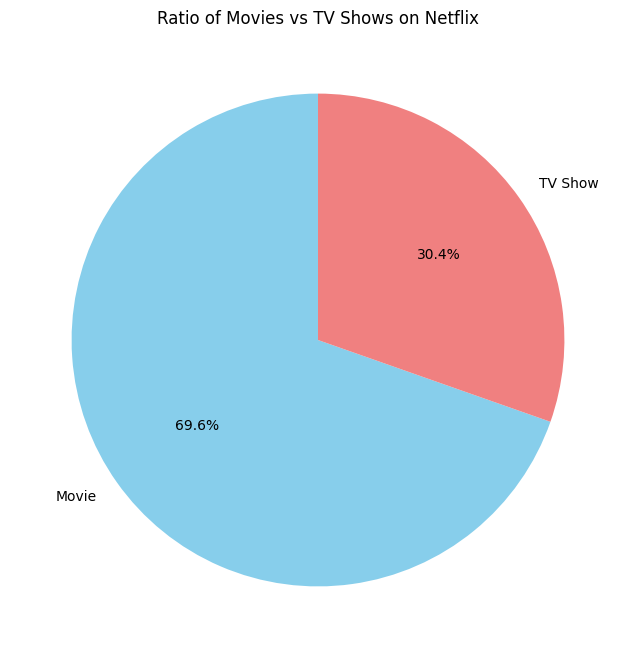

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Ratio of Movies vs TV Shows on Netflix')
plt.show()

**------2.Genres that are most popular on Netflix globally------**

In [ ]:
# Extract individual genres from the 'listed_in' column
genres = df['listed_in'].str.split(', ', expand=True).stack()

# Count the occurrences of each genre
genre_counts = genres.value_counts()

# Display the top 10 most popular genres
display(genre_counts.head(10))

,count
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641
Romantic Movies,616


/tmp/ipython-input-2681951474.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.head(10).index, y=genre_counts.head(10).values, palette='viridis')


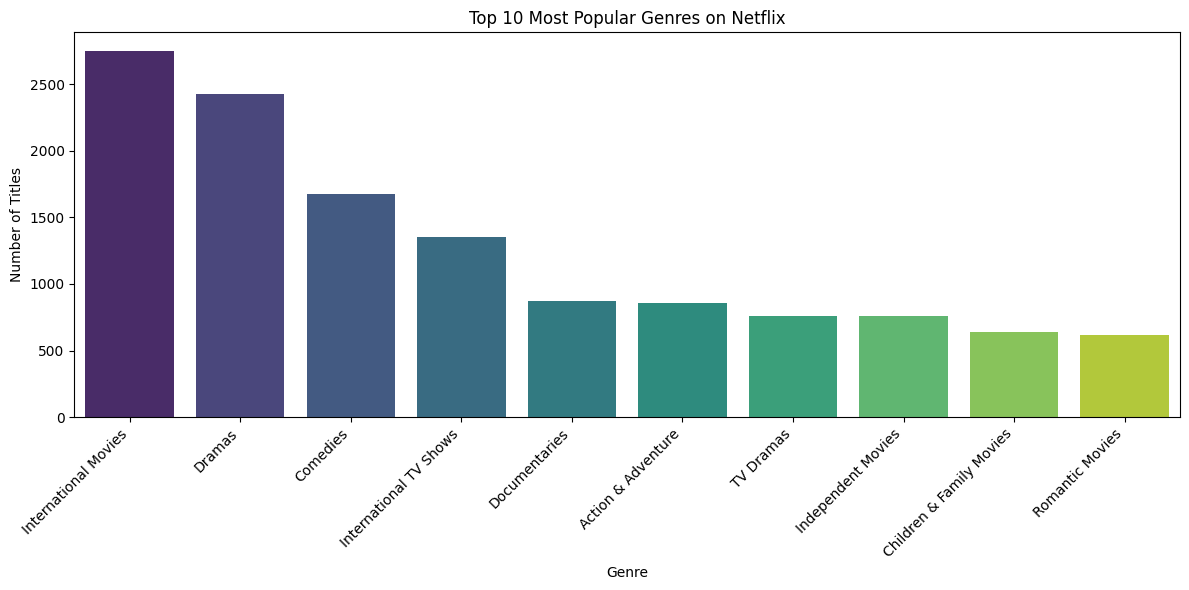

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.head(10).index, y=genre_counts.head(10).values, palette='viridis')
plt.title('Top 10 Most Popular Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**------3.The years that saw the highest release of content on Netflix------**

In [ ]:
release_year_counts = df['release_year'].value_counts()

# Display the top 10 years with the most releases
display(release_year_counts.head(10))

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


**------4.The countries which produce the most Netflix content------**

/tmp/ipython-input-2867080975.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')


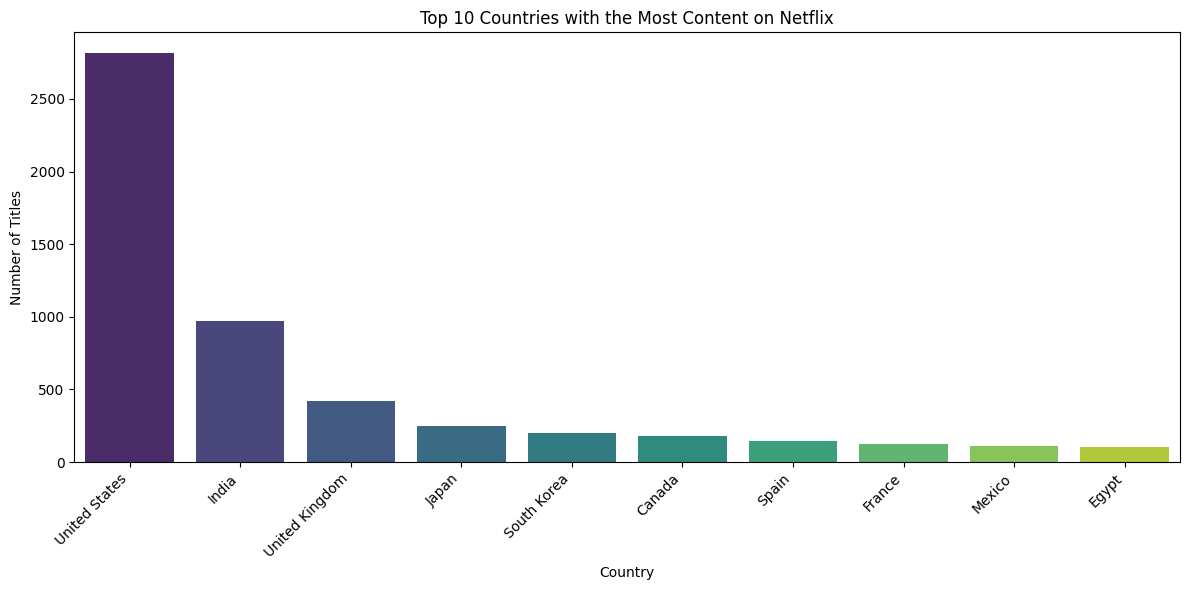

In [ ]:
country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')
plt.title('Top 10 Countries with the Most Content on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**------5.Trend of adding new content evolved year by year------**

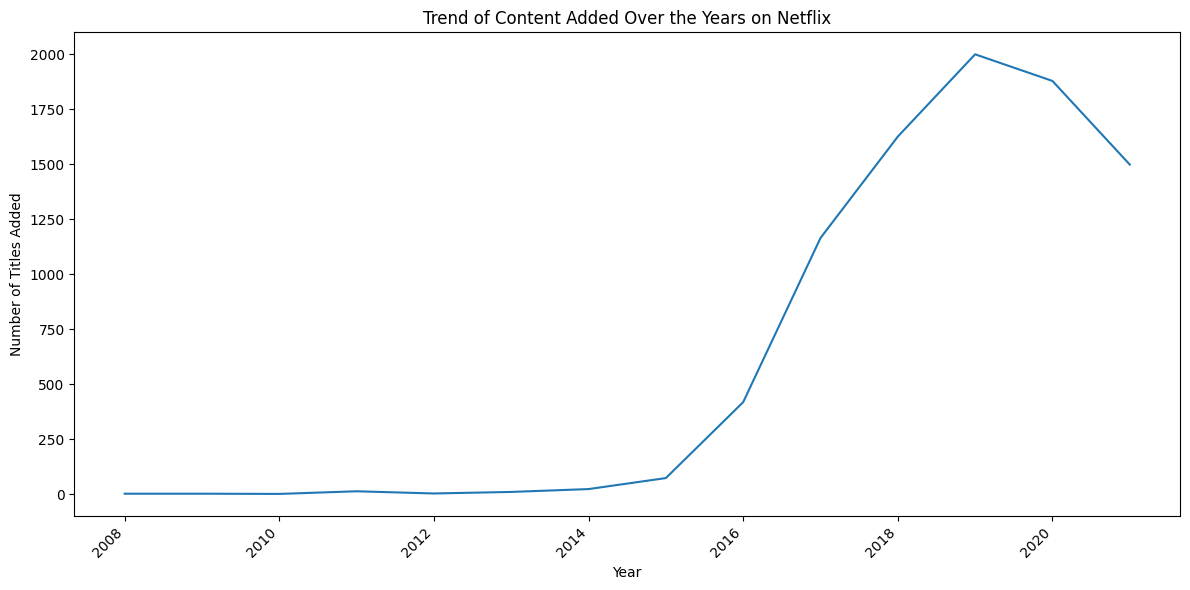

In [ ]:
# Convert 'date_added' to datetime and extract the year
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# Count the number of titles added each year
year_added_counts = df['year_added'].value_counts().sort_index()

# Visualize the trend
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_added_counts.index, y=year_added_counts.values)
plt.title('Trend of Content Added Over the Years on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###**QUESTION 2. User Demographics & Targeting**


**------6.The most frequent ratings on Netflix------**

/tmp/ipython-input-3767782355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')


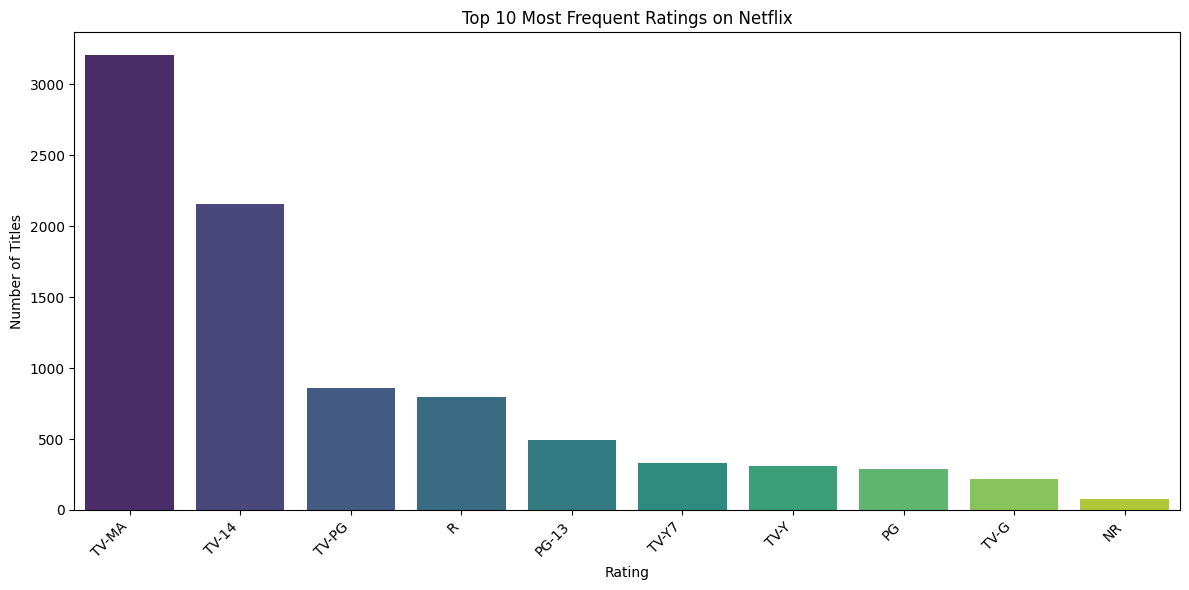

In [ ]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Top 10 Most Frequent Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**------7. The countries which tend to produce more mature content (TV-MA)------**

In [ ]:
# Filter the DataFrame for TV-MA rated content
tv_ma_content = df[df['rating'] == 'TV-MA']

# Count the occurrences of each country in the filtered data
tv_ma_country_counts = tv_ma_content['country'].value_counts()

# Display the top 10 countries with the most TV-MA content
display(tv_ma_country_counts.head(10))

,count
country,
United States,928
India,248
United Kingdom,177
Spain,119
Japan,87
South Korea,85
France,80
Mexico,77
Turkey,63


**------8. The genres which are more associated with TV Shows vs Movies------**

In [ ]:
#Split the DataFrame into two based on the 'type' column: one for movies and one for TV shows.
movies_df = df[df['type'] == 'Movie']
tv_shows_df = df[df['type'] == 'TV Show']

display(movies_df.head())
display(tv_shows_df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0


In [ ]:
#Count genres for each type
# For both the movie and TV show DataFrames,
# extract and count the occurrencesof each genre from the 'listed_in' column.
movie_genres = movies_df['listed_in'].str.split(', ', expand=True).stack()
movie_genre_counts = movie_genres.value_counts()

tv_show_genres = tv_shows_df['listed_in'].str.split(', ', expand=True).stack()
tv_show_genre_counts = tv_show_genres.value_counts()

display("Top 10 Movie Genres:")
display(movie_genre_counts.head(10))
display("Top 10 TV Show Genres:")
display(tv_show_genre_counts.head(10))

'Top 10 Movie Genres:'

,count
International Movies,2752
Dramas,2427
Comedies,1674
Documentaries,869
Action & Adventure,859
Independent Movies,756
Children & Family Movies,641
Romantic Movies,616
Thrillers,577
Music & Musicals,375


'Top 10 TV Show Genres:'

,count
International TV Shows,1351
TV Dramas,763
TV Comedies,581
Crime TV Shows,470
Kids' TV,451
Docuseries,395
Romantic TV Shows,370
Reality TV,255
British TV Shows,253
Anime Series,176


/tmp/ipython-input-1219494578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=movie_genre_counts.head(10).index, y=movie_genre_counts.head(10).values, palette='viridis')


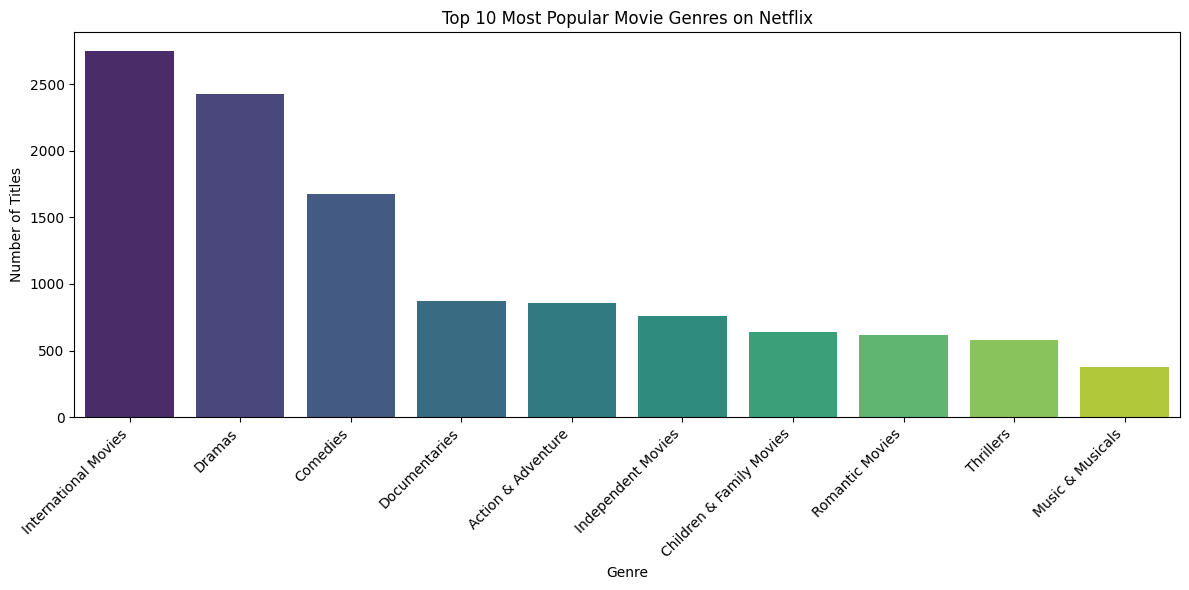

In [ ]:
#Visualize genre
#bar chart showing the most popular genres for movies.
plt.figure(figsize=(12, 6))
sns.barplot(x=movie_genre_counts.head(10).index, y=movie_genre_counts.head(10).values, palette='viridis')
plt.title('Top 10 Most Popular Movie Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1557460267.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tv_show_genre_counts.head(10).index, y=tv_show_genre_counts.head(10).values, palette='viridis')


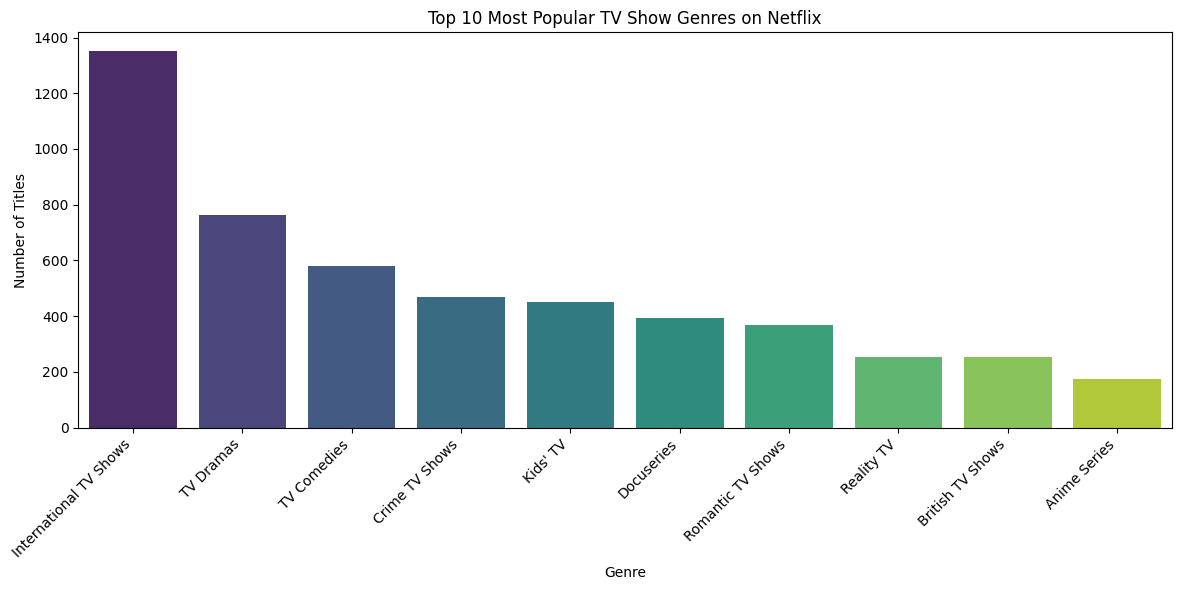

In [ ]:
#bar chart showing the most popular genres for TV shows.
plt.figure(figsize=(12, 6))
sns.barplot(x=tv_show_genre_counts.head(10).index, y=tv_show_genre_counts.head(10).values, palette='viridis')
plt.title('Top 10 Most Popular TV Show Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

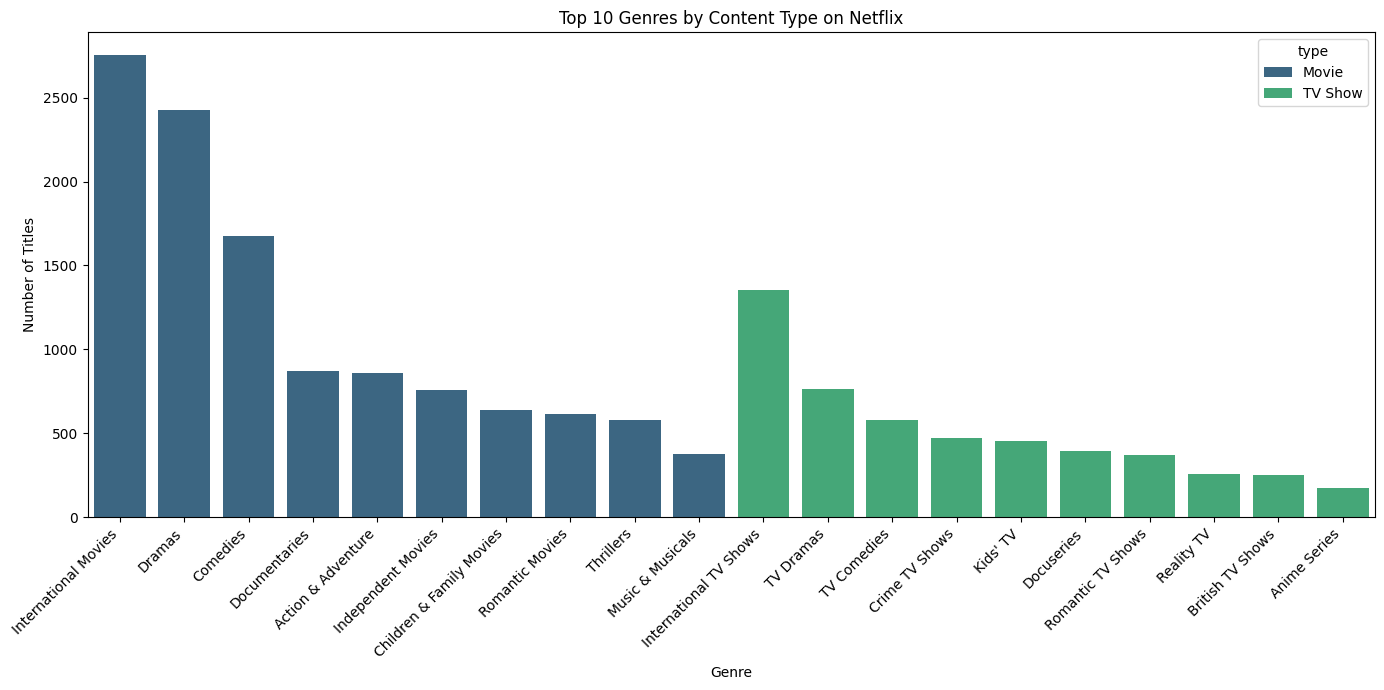

In [ ]:
# Combine the top 10 movie and TV show genre counts
#a combined visualization (e.g., grouped bar chart) to directly compare the genre distributions between movies and TV shows.
top_10_movie_genres = movie_genre_counts.head(10).reset_index()
top_10_movie_genres.columns = ['genre', 'count']
top_10_movie_genres['type'] = 'Movie'

top_10_tv_show_genres = tv_show_genre_counts.head(10).reset_index()
top_10_tv_show_genres.columns = ['genre', 'count']
top_10_tv_show_genres['type'] = 'TV Show'

combined_genre_counts = pd.concat([top_10_movie_genres, top_10_tv_show_genres])

# Create the grouped bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='genre', y='count', hue='type', data=combined_genre_counts, palette='viridis')
plt.title('Top 10 Genres by Content Type on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**------9.The genres which dominate the U.S. vs other countries------**

In [ ]:
#Separate data by country
us_content_df = df[df['country'] == 'United States'].copy()
other_countries_df = df[df['country'] != 'United States'].copy()

display(us_content_df.head())
display(other_countries_df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0
15,s16,TV Show,Dear White People,NaN,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,2021-09-22,2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...,2021.0
27,s28,Movie,Grown Ups,Dennis Dugan,"Adam Sandler, Kevin James, Chris Rock, David S...",United States,2021-09-20,2010,PG-13,103 min,Comedies,Mourning the loss of their beloved junior high...,2021.0
28,s29,Movie,Dark Skies,Scott Stewart,"Keri Russell, Josh Hamilton, J.K. Simmons, Dak...",United States,2021-09-19,2013,PG-13,97 min,"Horror Movies, Sci-Fi & Fantasy",A family’s idyllic suburban life shatters when...,2021.0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0


In [ ]:
#Count genres for each country group
us_genres = us_content_df['listed_in'].str.split(', ', expand=True).stack()
us_genre_counts = us_genres.value_counts()

other_countries_genres = other_countries_df['listed_in'].str.split(', ', expand=True).stack()
other_countries_genre_counts = other_countries_genres.value_counts()

display("Top 10 US Genres:")
display(us_genre_counts.head(10))
display("Top 10 Other Countries Genres:")
display(other_countries_genre_counts.head(10))

'Top 10 US Genres:'

,count
Dramas,591
Comedies,524
Documentaries,411
Independent Movies,302
Children & Family Movies,272
Action & Adventure,249
TV Comedies,234
Stand-Up Comedy,215
Thrillers,193
TV Dramas,189


'Top 10 Other Countries Genres:'

,count
International Movies,2731
Dramas,1836
International TV Shows,1324
Comedies,1150
Action & Adventure,610
TV Dramas,574
Documentaries,458
Independent Movies,454
Romantic Movies,443
Thrillers,384


In [ ]:
#Select top genres
N = 10
top_n_us_genres = us_genre_counts.head(N)
top_n_other_countries_genres = other_countries_genre_counts.head(N)

display("Top {} US Genres:".format(N))
display(top_n_us_genres)
display("Top {} Other Countries Genres:".format(N))
display(top_n_other_countries_genres)

'Top 10 US Genres:'

,count
Dramas,591
Comedies,524
Documentaries,411
Independent Movies,302
Children & Family Movies,272
Action & Adventure,249
TV Comedies,234
Stand-Up Comedy,215
Thrillers,193
TV Dramas,189


'Top 10 Other Countries Genres:'

,count
International Movies,2731
Dramas,1836
International TV Shows,1324
Comedies,1150
Action & Adventure,610
TV Dramas,574
Documentaries,458
Independent Movies,454
Romantic Movies,443
Thrillers,384


In [ ]:
#Combine and prepare data for visualization
top_n_us_genres_df = top_n_us_genres.reset_index()
top_n_us_genres_df.columns = ['genre', 'count']
top_n_us_genres_df['country_group'] = 'United States'

top_n_other_countries_genres_df = top_n_other_countries_genres.reset_index()
top_n_other_countries_genres_df.columns = ['genre', 'count']
top_n_other_countries_genres_df['country_group'] = 'Other Countries'

combined_top_genres = pd.concat([top_n_us_genres_df, top_n_other_countries_genres_df])

display(combined_top_genres.head())

,genre,count,country_group
0,Dramas,591,United States
1,Comedies,524,United States
2,Documentaries,411,United States
3,Independent Movies,302,United States
4,Children & Family Movies,272,United States


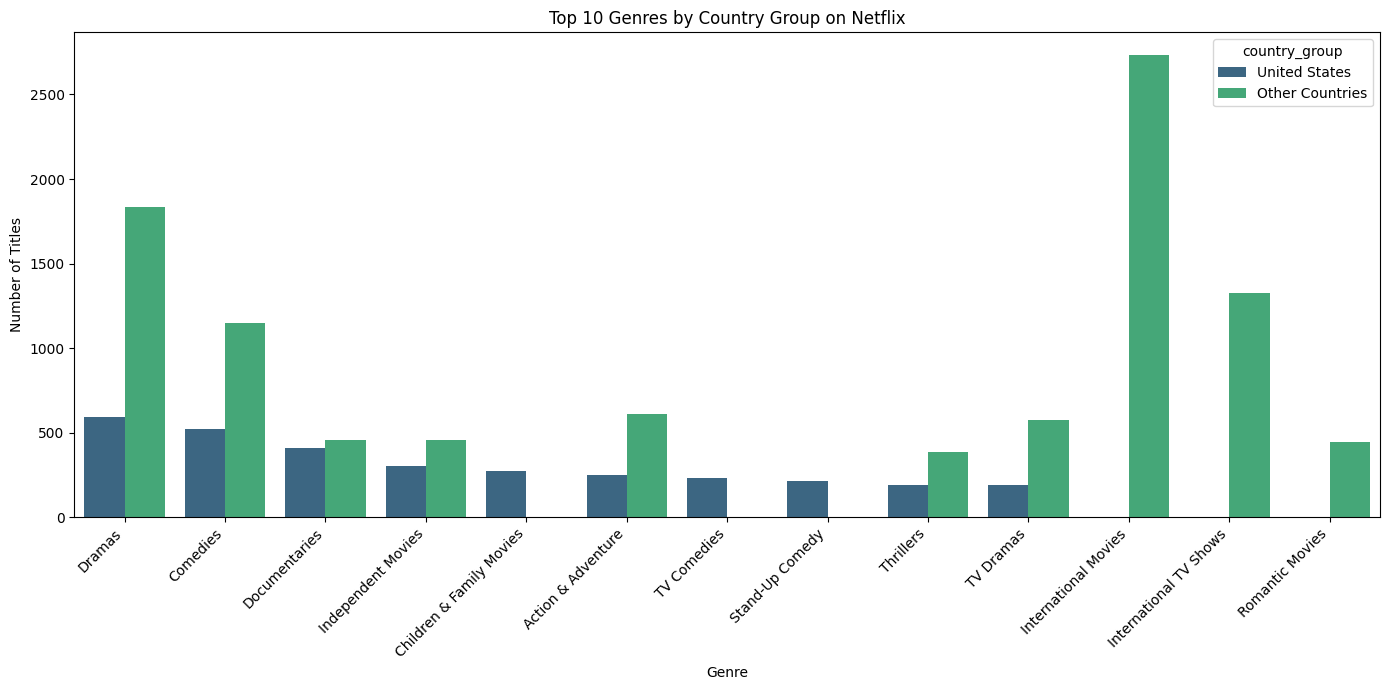

In [ ]:
#Visualize genre comparison
plt.figure(figsize=(14, 7))
sns.barplot(x='genre', y='count', hue='country_group', data=combined_top_genres, palette='viridis')
plt.title('Top 10 Genres by Country Group on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**------10.The genres that are most popular in the last 3 years-------**

In [ ]:
# Determine the last 3 years based on the data
latest_year = df['year_added'].max()
recent_years_df = df[df['year_added'] >= latest_year - 2].copy()

# Extract individual genres from the 'listed_in' column for the recent years
recent_genres = recent_years_df['listed_in'].str.split(', ', expand=True).stack()

# Count the occurrences of each genre in the recent years
recent_genre_counts = recent_genres.value_counts()

# Display the top 10 most popular genres in the last 3 years
display("Top 10 Most Popular Genres in the Last 3 Years:")
display(recent_genre_counts.head(10))

'Top 10 Most Popular Genres in the Last 3 Years:'

,count
International Movies,1593
Dramas,1511
Comedies,1135
International TV Shows,836
Action & Adventure,568
TV Dramas,463
Children & Family Movies,439
Independent Movies,438
Romantic Movies,437
Documentaries,405


###**QUESTION 3. Talent Acquisition & Partnerships**

**------11. The top 10 directors with the most Netflix content------**

In [ ]:
director_counts = df['director'].value_counts()

# Display the top 10 directors
display("Top 10 Directors with the Most Content on Netflix:")
display(director_counts.head(10))

'Top 10 Directors with the Most Content on Netflix:'

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12
Jay Chapman,12


**------12. Most frequently appearing actors in Netflix shows------**

In [ ]:
# Extract individual actors from the 'cast' column
actors = df['cast'].str.split(', ', expand=True).stack()

# Count the occurrences of each actor
actor_counts = actors.value_counts()

# Display the top 10 most frequent actors
display("Top 10 Most Frequent Actors on Netflix:")
display(actor_counts.head(10))

'Top 10 Most Frequent Actors on Netflix:'

,count
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30
Yuki Kaji,29
Amitabh Bachchan,28


**------13. The most frequent director-genre pairs------**

In [ ]:
#new DataFrame with only the 'director' and 'listed_in' columns
# drop rows with missing values
director_genre_df = df[['director', 'listed_in']].dropna()
display(director_genre_df.head())

,director,listed_in
0,Kirsten Johnson,Documentaries
2,Julien Leclercq,"Crime TV Shows, International TV Shows, TV Act..."
5,Mike Flanagan,"TV Dramas, TV Horror, TV Mysteries"
6,"Robert Cullen, José Luis Ucha",Children & Family Movies
7,Haile Gerima,"Dramas, Independent Movies, International Movies"


In [ ]:
#Split genres
director_genre_expanded = director_genre_df['listed_in'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True)
director_genre_expanded = pd.DataFrame({'director': director_genre_df['director'][director_genre_expanded.index], 'genre': director_genre_expanded.values})
display(director_genre_expanded.head())

,director,genre
0,Kirsten Johnson,Documentaries
2,Julien Leclercq,Crime TV Shows
2,Julien Leclercq,International TV Shows
2,Julien Leclercq,TV Action & Adventure
5,Mike Flanagan,TV Dramas


In [ ]:
#Count director-genre pairs
director_genre_pair_counts = director_genre_expanded.groupby(['director', 'genre']).size().reset_index(name='count')
director_genre_pair_counts = director_genre_pair_counts.sort_values(by='count', ascending=False)
display("Top 10 Director-Genre Pairs:")
display(director_genre_pair_counts.head(10))

'Top 10 Director-Genre Pairs:'

,director,genre,count
8097,Rajiv Chilaka,Children & Family Movies,19
8227,"Raúl Campos, Jan Suter",Stand-Up Comedy,18
9725,Suhas Kadav,Children & Family Movies,16
6150,Marcus Raboy,Stand-Up Comedy,15
1659,Cathy Garcia-Molina,International Movies,13
4251,Jay Karas,Stand-Up Comedy,13
4242,Jay Chapman,Stand-Up Comedy,12
10802,Youssef Chahine,Dramas,12
10804,Youssef Chahine,International Movies,10
6313,Martin Scorsese,Dramas,9


In [ ]:
#Display top pairs
N = 10
display("Top {} Most Frequent Director-Genre Pairs:".format(N))
display(director_genre_pair_counts.head(N))

'Top 10 Most Frequent Director-Genre Pairs:'

,director,genre,count
8097,Rajiv Chilaka,Children & Family Movies,19
8227,"Raúl Campos, Jan Suter",Stand-Up Comedy,18
9725,Suhas Kadav,Children & Family Movies,16
6150,Marcus Raboy,Stand-Up Comedy,15
1659,Cathy Garcia-Molina,International Movies,13
4251,Jay Karas,Stand-Up Comedy,13
4242,Jay Chapman,Stand-Up Comedy,12
10802,Youssef Chahine,Dramas,12
10804,Youssef Chahine,International Movies,10
6313,Martin Scorsese,Dramas,9


**------14. The most frequent director-genre pairs------**

In [ ]:
unknown_director_count = df['director'].isnull().sum()
unknown_cast_count = df['cast'].isnull().sum()

print(f"Number of titles with unknown directors: {unknown_director_count}")
print(f"Number of titles with unknown cast members: {unknown_cast_count}")

Number of titles with unknown directors: 2634
Number of titles with unknown cast members: 825


###**QUESTION 4. Duration & Engagement**

**------15. The average duration of Movies on Netflix------**

In [ ]:
movies_df_duration = df[df['type'] == 'Movie'].copy()
display(movies_df_duration.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0


In [ ]:
movies_df_duration['duration_minutes'] = pd.to_numeric(movies_df_duration['duration'].str.replace(' min', ''), errors='coerce')
display(movies_df_duration.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_minutes
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,90.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,91.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0,125.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0,104.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0,127.0


In [ ]:
average_movie_duration = movies_df_duration['duration_minutes'].mean()
print(f"The average duration of Movies on Netflix is: {average_movie_duration:.2f} minutes")

The average duration of Movies on Netflix is: 99.58 minutes


**------16. The most common number of seasons for TV shows------**

In [ ]:
tv_shows_duration = df[df['type'] == 'TV Show'].copy()
display(tv_shows_duration.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0


In [ ]:
#Extract number of seasons
tv_shows_duration['number_of_seasons'] = pd.to_numeric(tv_shows_duration['duration'].str.replace(' Seasons', '', regex=False), errors='coerce')
display(tv_shows_duration.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,number_of_seasons
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,2.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0,NaN


In [ ]:
#occurrences of each number of seasons
season_counts = tv_shows_duration['number_of_seasons'].value_counts()
display("Most common number of seasons for TV Shows:")
display(season_counts.head())

'Most common number of seasons for TV Shows:'

,count
number_of_seasons,
2.0,425
3.0,199
4.0,95
5.0,65
6.0,33


In [ ]:
most_common_seasons = season_counts.idxmax()
print(f"The most common number of seasons for TV Shows on Netflix is: {most_common_seasons}")

The most common number of seasons for TV Shows on Netflix is: 2.0


**------17. Trend in movie durations over the years------**

*   List item
*   List item



In [ ]:
movies_df_trend = df[df['type'] == 'Movie'].copy()
display(movies_df_trend.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0


In [ ]:
#Extract year and duration
movies_duration_trend = movies_df_trend[['release_year', 'duration']].copy()
display(movies_duration_trend.head())

,release_year,duration
0,2020,90 min
6,2021,91 min
7,1993,125 min
9,2021,104 min
12,2021,127 min


In [ ]:
#Convert duration to numeric
movies_duration_trend['duration_minutes'] = pd.to_numeric(movies_duration_trend['duration'].str.replace(' min', '', regex=False), errors='coerce')
display(movies_duration_trend.head())

,release_year,duration,duration_minutes
0,2020,90 min,90.0
6,2021,91 min,91.0
7,1993,125 min,125.0
9,2021,104 min,104.0
12,2021,127 min,127.0


In [ ]:
average_duration_per_year = movies_duration_trend.groupby('release_year')['duration_minutes'].mean().reset_index()
display(average_duration_per_year.head())

,release_year,duration_minutes
0,1942,35.000000
1,1943,62.666667
2,1944,52.000000
3,1945,51.333333
4,1946,58.000000


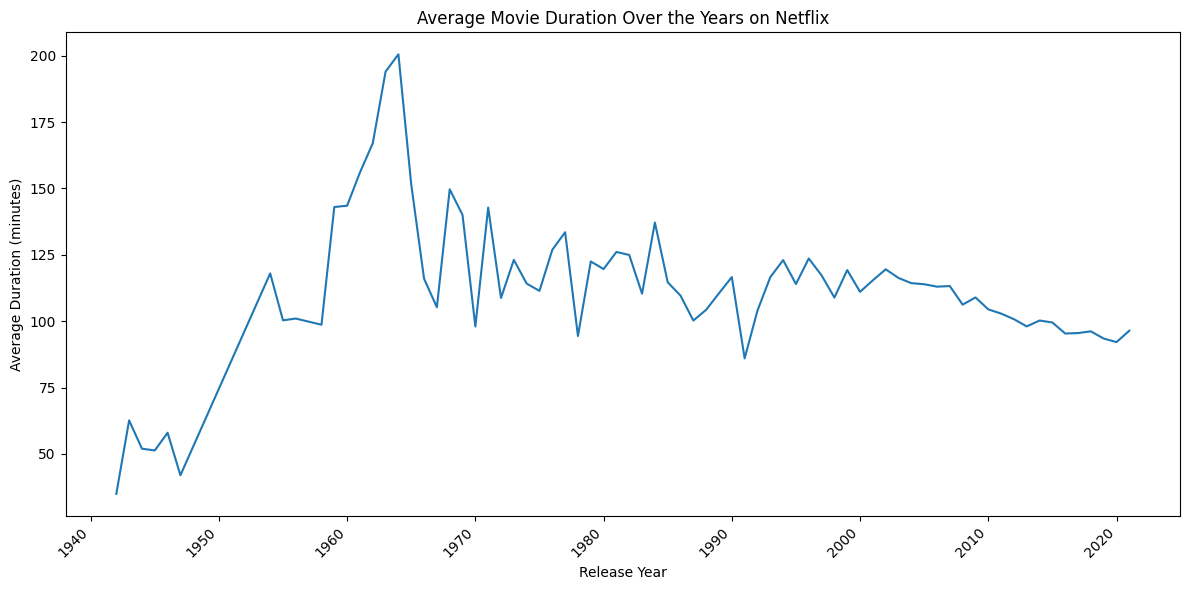

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='release_year', y='duration_minutes', data=average_duration_per_year)
plt.title('Average Movie Duration Over the Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###**QUESTION 5. Content Launch Strategy**

**------18. Which months does Netflix add the most content------**

In [ ]:
#Extract month
df['month_added'] = df['date_added'].dt.month
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [ ]:
month_counts = df['month_added'].value_counts().sort_index()
display("Months with the most content added:")
display(month_counts)

'Months with the most content added:'

,count
month_added,
1.0,727
2.0,557
3.0,734
4.0,759
5.0,626
6.0,724
7.0,819
8.0,749
9.0,765


/tmp/ipython-input-4135600736.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, palette='viridis')


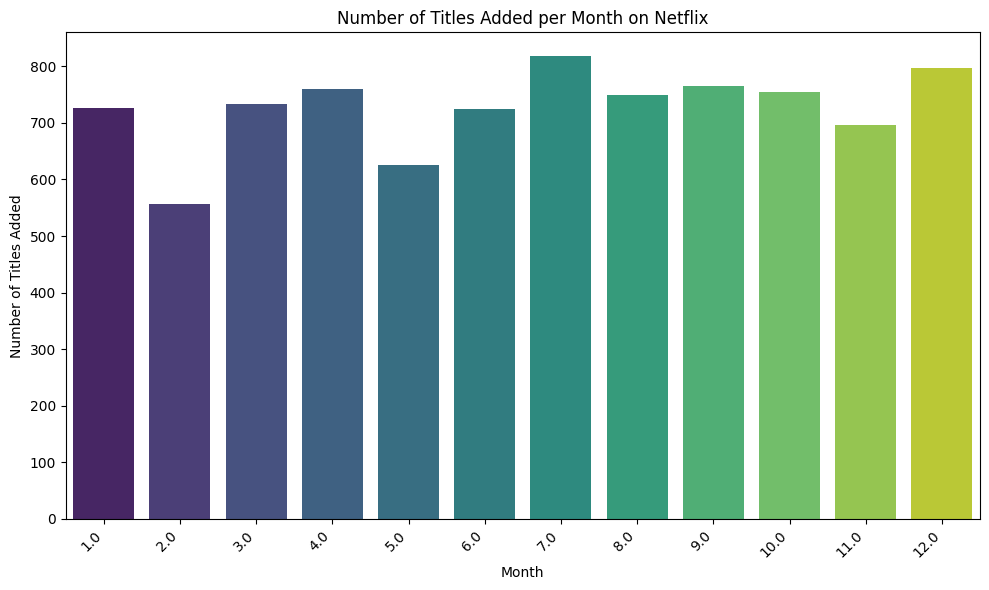

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=month_counts.index, y=month_counts.values, palette='viridis')
plt.title('Number of Titles Added per Month on Netflix')
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#Identify peak months
most_common_month = month_counts.idxmax()
count_of_most_common_month = month_counts.max()

print(f"The month with the highest content additions is Month {most_common_month} with {count_of_most_common_month} titles added.")

The month with the highest content additions is Month 7.0 with 819 titles added.


**------19. The genre distribution vary across different years------**

In [ ]:
#Extract year and genres
year_genre_df = df[['year_added', 'listed_in']].dropna()
display(year_genre_df.head())

,year_added,listed_in
0,2021.0,Documentaries
1,2021.0,"International TV Shows, TV Dramas, TV Mysteries"
2,2021.0,"Crime TV Shows, International TV Shows, TV Act..."
3,2021.0,"Docuseries, Reality TV"
4,2021.0,"International TV Shows, Romantic TV Shows, TV ..."


In [ ]:
#Split genres
year_genre_expanded = year_genre_df['listed_in'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True)
year_genre_expanded = pd.DataFrame({'year_added': year_genre_df['year_added'][year_genre_expanded.index], 'genre': year_genre_expanded.values})
display(year_genre_expanded.head())

,year_added,genre
0,2021.0,Documentaries
1,2021.0,International TV Shows
1,2021.0,TV Dramas
1,2021.0,TV Mysteries
2,2021.0,Crime TV Shows


In [ ]:
#Count genre occurrences by year
genre_counts_by_year = year_genre_expanded.groupby(['year_added', 'genre']).size().reset_index(name='count')
display(genre_counts_by_year.head())

,year_added,genre,count
0,2008.0,Dramas,1
1,2008.0,Independent Movies,1
2,2008.0,Stand-Up Comedy & Talk Shows,1
3,2008.0,Thrillers,1
4,2009.0,Dramas,1


In [ ]:
top_genres_per_year = genre_counts_by_year.groupby('year_added').apply(lambda x: x.nlargest(5, 'count')).reset_index(drop=True)
display("Top 5 Genres per Year:")
display(top_genres_per_year)

/tmp/ipython-input-2618218232.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_genres_per_year = genre_counts_by_year.groupby('year_added').apply(lambda x: x.nlargest(5, 'count')).reset_index(drop=True)


'Top 5 Genres per Year:'

,year_added,genre,count
0,2008.0,Dramas,1
1,2008.0,Independent Movies,1
2,2008.0,Stand-Up Comedy & Talk Shows,1
3,2008.0,Thrillers,1
4,2009.0,Dramas,1
...,...,...,...
57,2021.0,Dramas,412
58,2021.0,International Movies,408
59,2021.0,Comedies,299
60,2021.0,International TV Shows,229


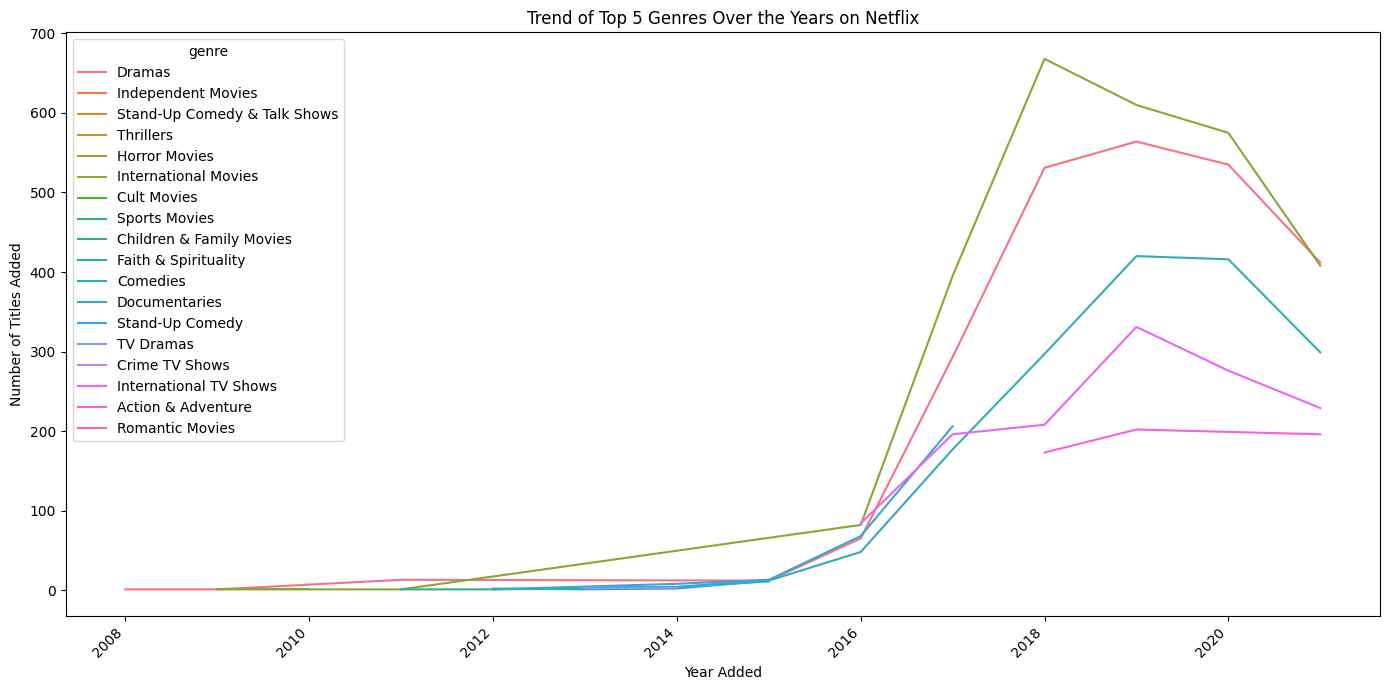

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='year_added', y='count', hue='genre', data=top_genres_per_year)
plt.title('Trend of Top 5 Genres Over the Years on Netflix')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**------20. Countries which produce the most content in each genre------**

In [ ]:
country_genre_df = df[['country', 'listed_in']].dropna()
display(country_genre_df.head())

,country,listed_in
0,United States,Documentaries
1,South Africa,"International TV Shows, TV Dramas, TV Mysteries"
4,India,"International TV Shows, Romantic TV Shows, TV ..."
7,"United States, Ghana, Burkina Faso, United Kin...","Dramas, Independent Movies, International Movies"
8,United Kingdom,"British TV Shows, Reality TV"


In [ ]:
# Split the 'listed_in' column into individual genres and stack them
country_genre_expanded = country_genre_df['listed_in'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True)

# Create a new DataFrame with 'country' and 'genre' pairs
country_genre_expanded = pd.DataFrame({'country': country_genre_df['country'][country_genre_expanded.index], 'genre': country_genre_expanded.values})

# Count the occurrences of each unique country-genre pair
country_genre_pair_counts = country_genre_expanded.groupby(['country', 'genre']).size().reset_index(name='count')

display(country_genre_pair_counts.head())

,country,genre,count
0,", France, Algeria",Dramas,1
1,", France, Algeria",Independent Movies,1
2,", France, Algeria",International Movies,1
3,", South Korea",International TV Shows,1
4,", South Korea",TV Dramas,1


In [ ]:
# Identify the dominant country for each genre
dominant_country_per_genre = country_genre_pair_counts.loc[country_genre_pair_counts.groupby('genre')['count'].idxmax()]

# Display the dominant country for each genre
display("Dominant Country for Each Genre:")
display(dominant_country_per_genre.head())

'Dominant Country for Each Genre:'

,country,genre,count
2459,United States,Action & Adventure,249
1262,Japan,Anime Features,54
1263,Japan,Anime Series,131
2134,United Kingdom,British TV Shows,196
2463,United States,Children & Family Movies,272


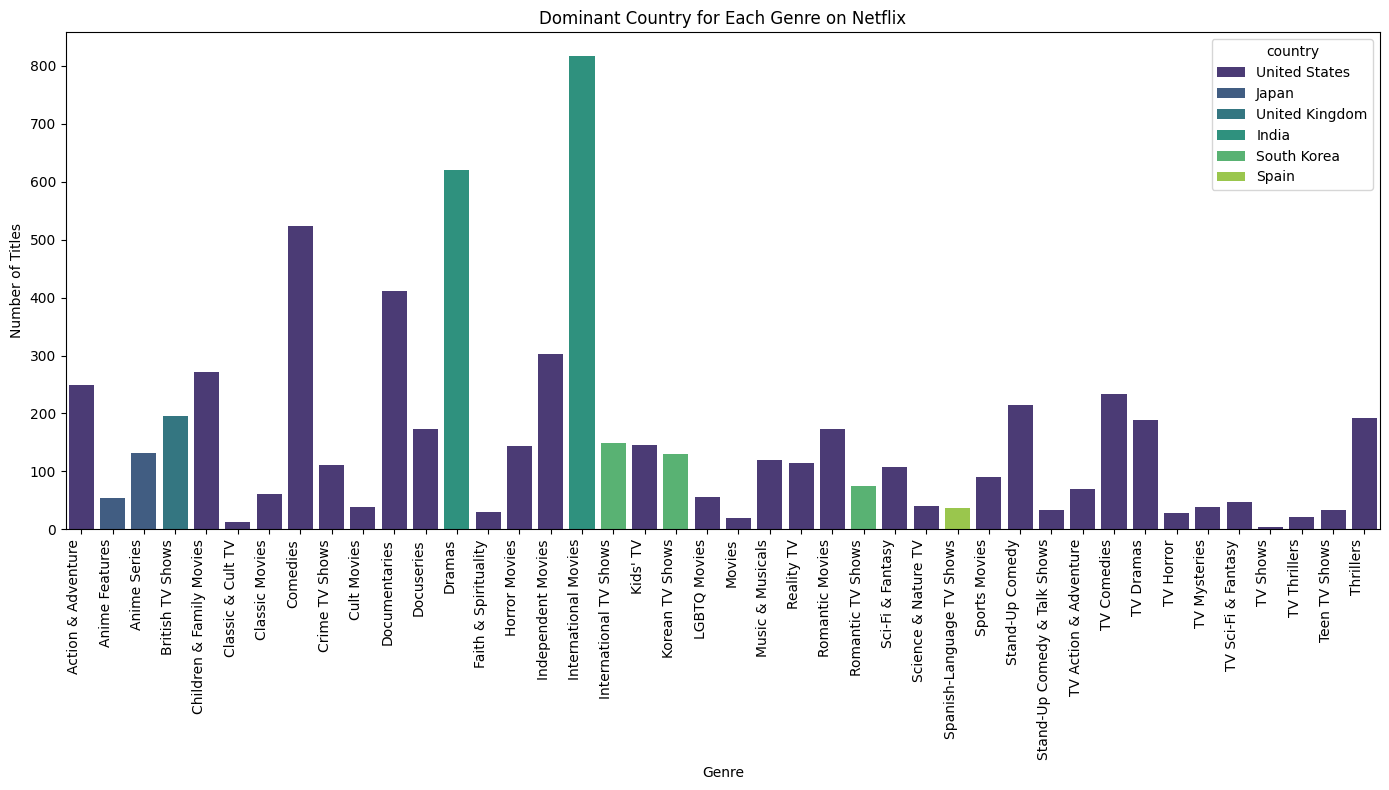

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='genre', y='count', hue='country', data=dominant_country_per_genre, palette='viridis', dodge=False)
plt.title('Dominant Country for Each Genre on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

This bar chart shows the dominant country for each genre on Netflix based on the number of titles. Each bar represents a genre, and the color of the bar indicates the country that has produced the most content in that specific genre. The height of the bar corresponds to the number of titles produced by that dominant country in that genre. This visualization helps to quickly identify which countries specialize in or produce the highest volume of content within different genres on the platform.

----------------------------------------------------------********---------------------------------------------------------------